# Machine-Learning Trading Signal with Alpaca (Paper Trading Only)

**Homework 3.** Build a simple ML trading signal on Alpaca market data,
evaluate it with a backtest, and demo it in Alpaca's **paper** environment.

> ⚠️ **This is PAPER TRADING ONLY — no real money is used.**

Pipeline: **Data → Features → PCA → ML model → Signal → Backtest → Metrics → Paper trade.**


In [1]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd

from src.data import get_daily_ohlcv
from src.features import build_features, FEATURE_COLUMNS
from src.model import train_signal_model
from src.backtest import run_backtest
from src.metrics import metrics_table
from src.plotting import (plot_pca_variance, plot_equity_curves,
                          plot_drawdowns, plot_signal)

TICKER = "SPY"       # try AAPL, MSFT, QQQ, NVDA …
MODEL  = "gradient_boosting"
THRESHOLD = 0.60
print("Config:", TICKER, MODEL, "threshold", THRESHOLD)

Config: SPY gradient_boosting threshold 0.6


## 1 · Data Collection — 5 years of daily OHLCV from Alpaca

In [2]:
df = get_daily_ohlcv(TICKER, years=5)
print(f"{len(df)} bars: {df.index[0].date()} -> {df.index[-1].date()}")
df.tail()

1257 bars: 2021-07-06 -> 2026-07-08


,open,high,low,close,volume
date,,,,,
2026-07-01 04:00:00,744.965,749.410,742.385,745.665,1546434.0
2026-07-02 04:00:00,747.415,751.230,740.040,744.860,1955793.0
2026-07-06 04:00:00,748.220,752.400,747.455,751.270,1521390.0
2026-07-07 04:00:00,750.210,750.935,745.270,747.770,1436097.0
2026-07-08 04:00:00,743.135,746.140,739.550,745.280,1223246.0


## 2 · Feature Engineering

11 indicators (trend / momentum / volatility / volume) + **log returns** + **rolling mean & std**.

In [3]:
feat = build_features(df)
print(f"{len(FEATURE_COLUMNS)} feature columns")
feat[FEATURE_COLUMNS].tail()

29 feature columns


,sma20,sma50,ema20,ema50,ema200,macd,macd_signal,macd_hist,adx,plus_di,...,atr,obv,cmf,log_return,roll_mean_5,roll_mean_10,roll_mean_20,roll_std_5,roll_std_10,roll_std_20
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 04:00:00,741.49950,736.5643,740.885891,731.561300,690.593905,1.055111,1.680762,-0.625651,22.838387,20.445537,...,10.002357,19697792.0,-0.132473,-0.001320,0.003339,-0.000657,-0.000917,0.008387,0.009282,0.011257
2026-07-02 04:00:00,741.03350,737.3833,741.264378,732.082818,691.133866,1.289367,1.602483,-0.313116,22.575531,18.825480,...,10.087188,17741999.0,-0.102710,-0.001080,0.003120,0.000517,-0.000622,0.008509,0.008259,0.011167
2026-07-06 04:00:00,740.74850,738.1847,742.217294,732.835256,691.732236,1.969546,1.675896,0.293650,22.171463,18.645603,...,9.905246,19263389.0,-0.105685,0.008569,0.005922,0.000603,-0.000378,0.007189,0.008347,0.011318
2026-07-07 04:00:00,741.26450,738.9719,742.746123,733.420933,692.289826,2.200802,1.780877,0.419925,22.012429,17.815484,...,9.626300,17827292.0,-0.057194,-0.004670,0.001857,0.000469,0.000695,0.005948,0.008428,0.009642
2026-07-08 04:00:00,741.56675,739.5981,742.987445,733.885994,692.817091,2.158273,1.856356,0.301917,22.397303,16.717395,...,9.525850,16604046.0,-0.003282,-0.003335,-0.000367,0.001577,0.000407,0.005210,0.006831,0.009674


## 3 · PCA

Standardize the features and keep the components explaining **≥80%** of the variance. PCA is fit on the **training window only** (no look-ahead).

Kept 4 components — 83.0% variance


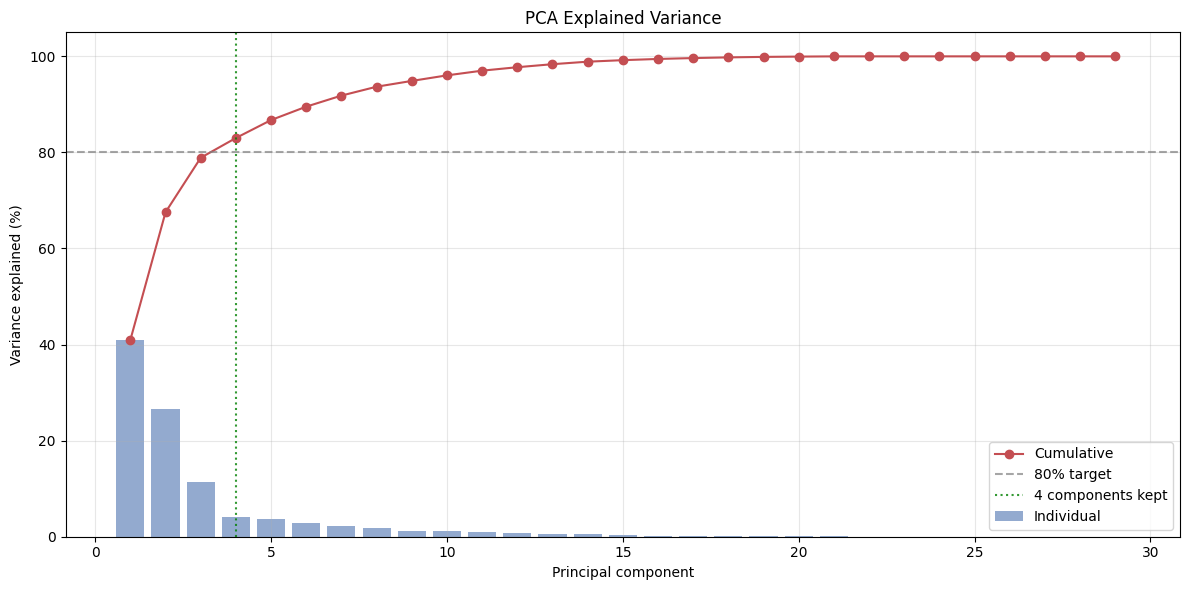

In [4]:
sm = train_signal_model(df, model=MODEL, threshold=THRESHOLD)
kept = sm.pca.n_components
print(f"Kept {kept} components — "
      f"{sm.pca.explained_variance_ratio[:kept].sum()*100:.1f}% variance")
fig = plot_pca_variance(sm.pca); plt.show()

## 4 · ML Model & Signal

Target = **next-day return > 0**. Signal = **Long** if P(up) > 0.60, else **Flat**.

Model: gradient_boosting
Test window: 2025-01-24 -> 2026-07-07 (363 days)
LONG on 93/363 test days


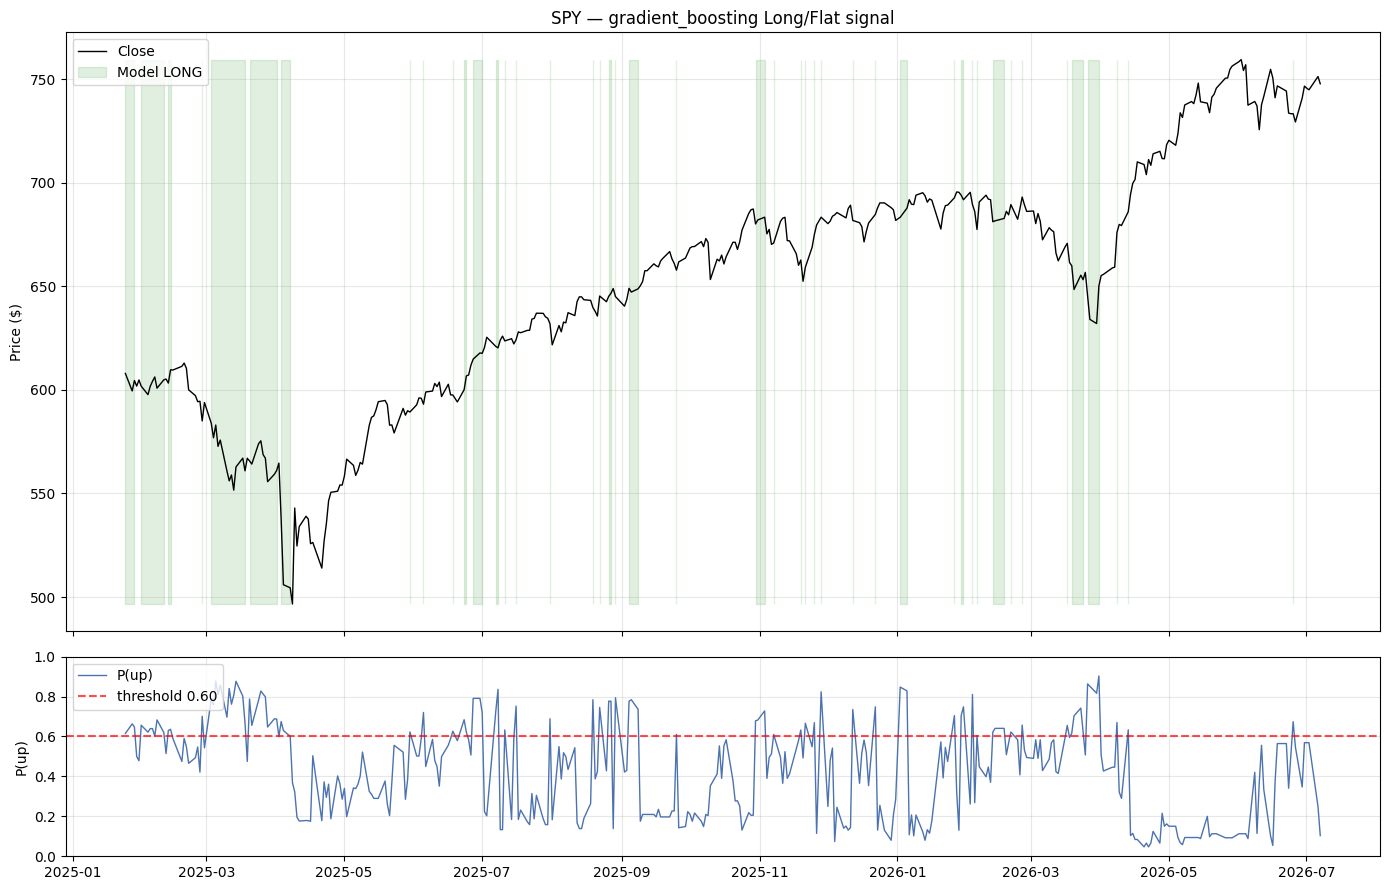

In [5]:
print(f"Model: {sm.name}")
print(f"Test window: {sm.test_index[0].date()} -> {sm.test_index[-1].date()} "
      f"({len(sm.test_index)} days)")
print(f"LONG on {int(sm.signal.sum())}/{len(sm.signal)} test days")
df_test = sm.test_frame()
fig = plot_signal(df_test, sm.proba, sm.signal, sm.threshold,
                  f"{TICKER} — {MODEL} Long/Flat signal"); plt.show()

## 5 · Backtest — ML Signal vs Buy & Hold

$100k, long-only, no leverage, no shorting. Positions act on the next bar.

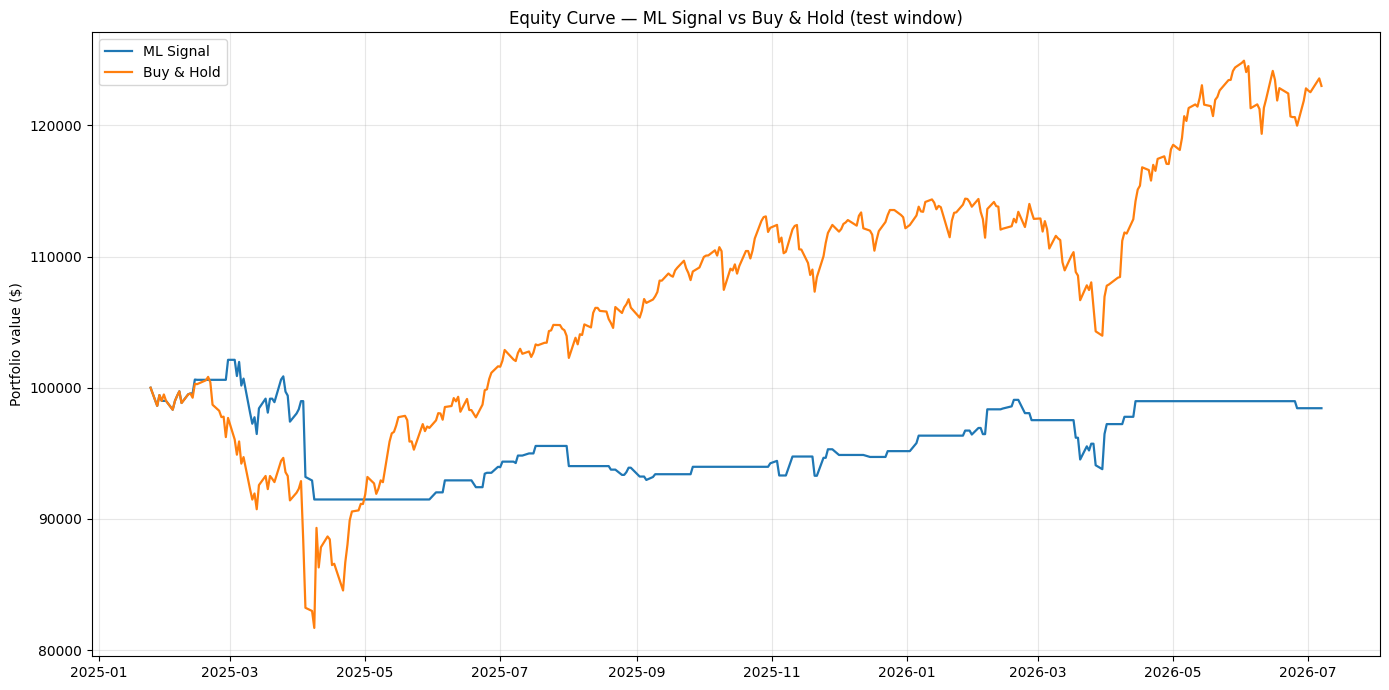

In [6]:
ml = run_backtest(df_test, sm.signal, initial_capital=100_000)
bh = run_backtest(df_test, pd.Series(1, index=df_test.index), initial_capital=100_000)
results = {"ML Signal": ml, "Buy & Hold": bh}
fig = plot_equity_curves(results); plt.show()

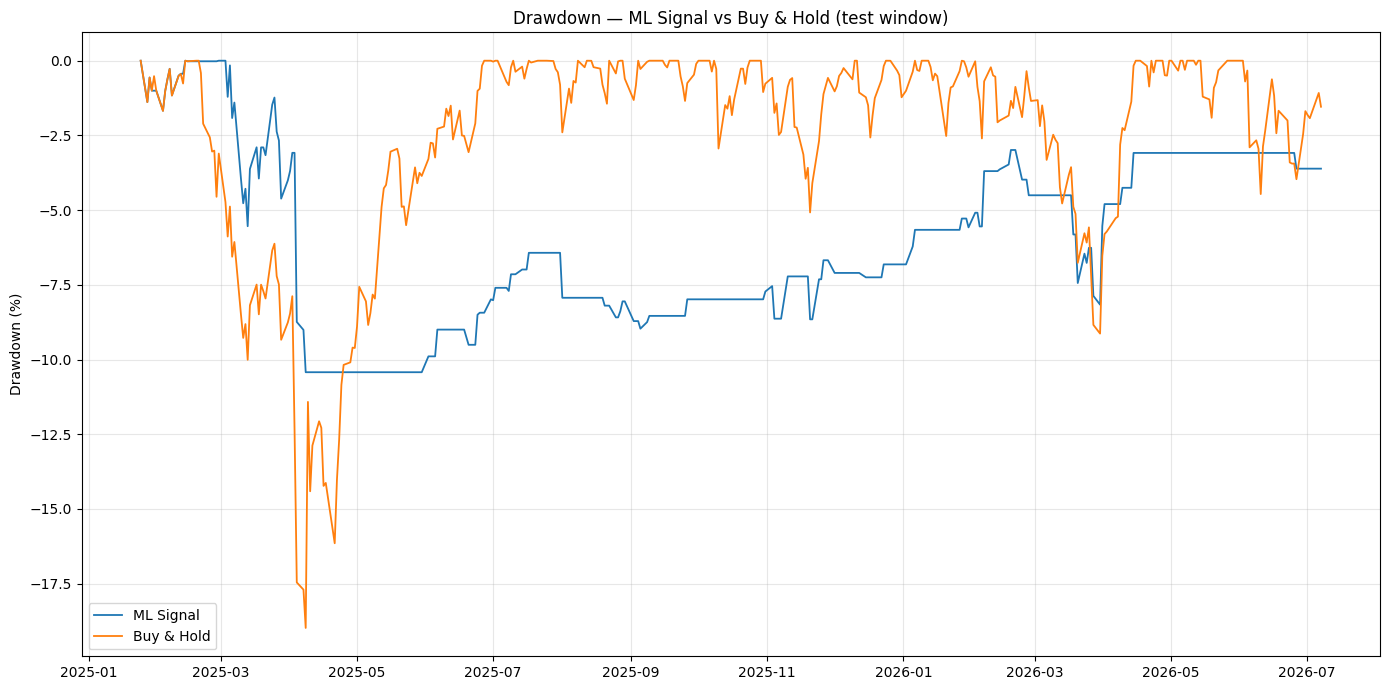

In [7]:
fig = plot_drawdowns(results); plt.show()

## 6 · Performance Metrics

Total Return, CAGR, Volatility, Sharpe, Sortino, Max Drawdown, Win Rate.

In [8]:
metrics_table(results)

,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Win Rate,Trades
ML Signal,-1.56%,-1.09%,9.22%,-0.07,-0.04,-10.42%,63.64%,44
Buy & Hold,23.00%,15.46%,17.24%,0.92,1.20,-18.98%,100.00%,1


## 7 · Paper Trading Demo

Run from a terminal (submits a **paper** order to Alpaca):

```bash
python paper_trade.py --ticker AAPL --qty 5           # follow the model
python paper_trade.py --ticker AAPL --qty 5 --force buy  # guarantee a demo trade
```

The script fetches the latest data, rebuilds features, applies PCA, generates
the ML signal, and submits a **BUY** (Long) or **SELL** (Flat) order to the
Alpaca paper endpoint. See the README for the dashboard screenshot + logs.

> ⚠️ **PAPER TRADING ONLY — no real money is used.**